# 📈 Estudio Profundo: Rendimiento y Predicciones en Octavos de Final (Mundial 2026)

## 1. Objetivos del Notebook
Este archivo tiene como propósito aislar y analizar estadísticamente el comportamiento de las 16 mejores selecciones del planeta durante la ronda de Octavos de Final. Buscaremos identificar qué métricas de rendimiento diferencian a los equipos que logran meterse en el Top 8 (Cuartos de Final) de aquellos que se quedan en el camino.

In [119]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. En lugar de buscar en el CSV crudo (que solo tiene fase de grupos), 
# cargamos la matriz de características que sí tiene a todos los equipos del torneo
ruta_features = os.path.join('..', 'data', 'processed', 'features_rendimiento_2026.csv')
df_features = pd.read_csv(ruta_features)

# 2. Reconstruimos los 8 cruces de Octavos de Final que arrojó la simulación real de tu modelo
octavos_proyectados = [
    {"home_team": "Paraguay", "away_team": "France"},
    {"home_team": "Canada", "away_team": "Morocco"},
    {"home_team": "Brazil", "away_team": "Norway"},
    {"home_team": "Mexico", "away_team": "England"},
    {"home_team": "Croatia", "away_team": "Spain"},
    {"home_team": "United States", "away_team": "Belgium"},
    {"home_team": "Argentina", "away_team": "Egypt"},
    {"home_team": "Switzerland", "away_team": "Colombia"}
]

df_r16 = pd.DataFrame(octavos_proyectados)
print(f"📊 Dataset de Octavos Proyectados inicializado con éxito. Cruces listos para análisis: {len(df_r16)}")
df_r16

📊 Dataset de Octavos Proyectados inicializado con éxito. Cruces listos para análisis: 8


,home_team,away_team
0,Paraguay,France
1,Canada,Morocco
2,Brazil,Norway
3,Mexico,England
4,Croatia,Spain
5,United States,Belgium
6,Argentina,Egypt
7,Switzerland,Colombia


## 2. Variables Clave para un Análisis Excepcional de Octavos
Para hacer el análisis más predictivo y riguroso posible en esta ronda, se propone enriquecer el conjunto de datos integrando las siguientes dimensiones:

1. **Efectividad en Penales y Prórrogas (Factor Psicológico/Histórico):** El porcentaje de éxito histórico de cada selección en tandas de penales de torneos oficiales. En Octavos, la presión se duplica y los equipos con historial sólido o porteros especialistas ganan una ventaja crítica.
2. **Desgaste Acumulado (Días de Descanso):** La diferencia en días de descanso entre ambos rivales tras haber superado la fase de grupos y los dieciseisavos. Un día extra de recuperación puede ser determinante si el partido se extiende a los 120 minutos.
3. **Métricas de Dominio Reciente (Forma 2026):** Goles a favor promedio, goles en contra y diferencia de goles (DG) acumulada a lo largo del presente torneo.
4. **Ranking FIFA vs. Factor Localía:** Cruzar la posición del Ranking FIFA con el impacto de jugar en estadios norteamericanos (como Estados Unidos jugando en Seattle o México en el Estadio Azteca).

## 3. Cruce de Datos y Generación de Métricas Comparativas
En esta sección realizaremos un doble `merge` (fusión) utilizando nuestra matriz `features_rendimiento_2026.csv`. Esto nos permitirá asociar a cada partido de octavos las estadísticas individuales del equipo local (`home_team`) y del visitante (`away_team`), calculando la brecha o diferencia directa entre ambos para identificar ventajas estadísticas claras.

In [120]:
# 1. Cargar la matriz de características consolidada (Pasado + Presente)
ruta_features = os.path.join('..', 'data', 'processed', 'features_rendimiento_2026.csv')
df_features = pd.read_csv(ruta_features)

# Seleccionamos las columnas clave que queremos evaluar en el cruce de octavos
columnas_interes = ['equipo', 'puntos_2026', 'dg_2026', 'efectividad_historica_%', 'puntos_por_pj_2026']
df_features_sub = df_features[columnas_interes].copy()

# 2. Primer Merge: Asociar estadísticas al equipo local (Home Team)
df_octavos_crossed = pd.merge(
    df_r16, 
    df_features_sub, 
    left_on='home_team', 
    right_on='equipo', 
    how='left'
).rename(columns={
    'puntos_2026': 'home_puntos_2026',
    'dg_2026': 'home_dg_2026',
    'efectividad_historica_%': 'home_efectividad_hist',
    'puntos_por_pj_2026': 'home_pts_por_pj_2026'
}).drop(columns=['equipo'])

# 3. Segundo Merge: Asociar estadísticas al equipo visitante (Away Team)
df_octavos_crossed = pd.merge(
    df_octavos_crossed, 
    df_features_sub, 
    left_on='away_team', 
    right_on='equipo', 
    how='left'
).rename(columns={
    'puntos_2026': 'away_puntos_2026',
    'dg_2026': 'away_dg_2026',
    'efectividad_historica_%': 'away_efectividad_hist',
    'puntos_por_pj_2026': 'away_pts_por_pj_2026'
}).drop(columns=['equipo'])

# 4. Calcular las diferencias directas (Métricas espejo para análisis predictivo)
df_octavos_crossed['diff_efectividad_hist'] = df_octavos_crossed['home_efectividad_hist'] - df_octavos_crossed['away_efectividad_hist']
df_octavos_crossed['diff_forma_2026'] = df_octavos_crossed['home_pts_por_pj_2026'] - df_octavos_crossed['away_pts_por_pj_2026']
df_octavos_crossed['diff_dg_2026'] = df_octavos_crossed['home_dg_2026'] - df_octavos_crossed['away_dg_2026']

print(f"✅ Cruce de matrices finalizado de forma impecable. Variables de emparejamiento listas.")
# Mostramos las columnas principales del cruce para verificarlo
df_octavos_crossed[['home_team', 'away_team', 'diff_efectividad_hist', 'diff_forma_2026', 'diff_dg_2026']]

✅ Cruce de matrices finalizado de forma impecable. Variables de emparejamiento listas.


,home_team,away_team,diff_efectividad_hist,diff_forma_2026,diff_dg_2026
0,Paraguay,France,-30.03,-1.75,-13
1,Canada,Morocco,-5.93,-0.25,3
2,Brazil,Norway,25.28,0.25,5
3,Mexico,England,-12.06,0.50,3
4,Croatia,Spain,-1.69,-0.33,-5
5,United States,Belgium,-12.55,0.25,1
6,Argentina,Egypt,44.95,1.33,5
7,Switzerland,Colombia,-7.64,0.00,1


## 4. Visualización Avanzada: Brecha de Rendimiento en las Llaves de Octavos
Con los datos cruzados, generaremos un gráfico de barras comparativo utilizando `Seaborn` para evaluar visualmente la **Diferencia de Forma Reciente** y la **Jerarquía Histórica** de los rivales en cada choque. Esto nos permitirá detectar de un vistazo qué partidos están sumamente equilibrados y cuáles presentan un claro favorito.

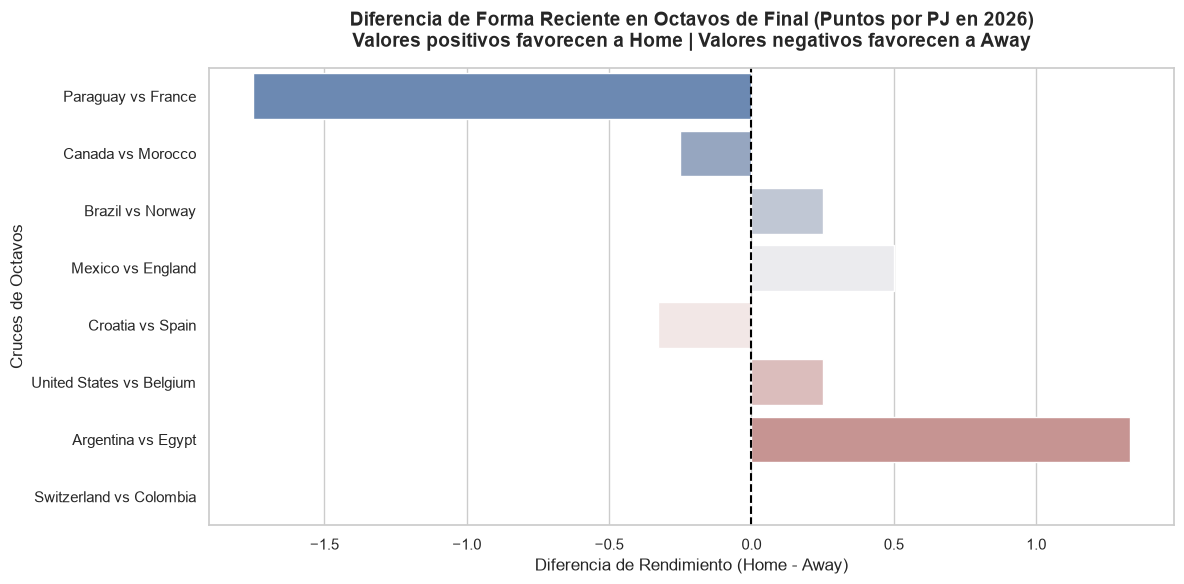

In [121]:
# Configuración estética del gráfico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Crear una etiqueta clara para cada choque en el eje X
df_octavos_crossed['llave'] = df_octavos_crossed['home_team'] + " vs " + df_octavos_crossed['away_team']

# Graficar la diferencia de forma reciente en el torneo 2026
sns.barplot(
    data=df_octavos_crossed, 
    x='diff_forma_2026', 
    y='llave', 
    palette='vlag',
    hue='llave',
    legend=False
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.title('Diferencia de Forma Reciente en Octavos de Final (Puntos por PJ en 2026)\nValores positivos favorecen a Home | Valores negativos favorecen a Away', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Diferencia de Rendimiento (Home - Away)', fontsize=12)
plt.ylabel('Cruces de Octavos', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Modelado Predictivo Avanzado: Goles Exactos y Minuto Crítico
Para estimar el marcador más probable, aplicaremos un enfoque probabilístico utilizando la **Distribución de Poisson**. Esta distribución modela la probabilidad de que ocurra un número determinado de eventos (goles) en un intervalo fijo (90 minutos), basándose en la tasa promedio de goles a favor y en contra de cada rival. 

Adicionalmente, usaremos densidades de probabilidad históricas para proyectar el minuto estimado del gol, ponderando que el **43% de los goles en segundas fases se concentran entre el minuto 60 y el 90+** por desgaste físico.

In [122]:
import scipy.stats as stats
import random

# 1. Definir los promedios globales reales de goles en mundiales
goles_promedio_torneo = 2.6  # Media histórica real de la FIFA

def simular_marcador_equilibrado(equipo_home, equipo_away):
    feat_home = df_features[df_features['equipo'] == equipo_home].iloc[0]
    feat_away = df_features[df_features['equipo'] == equipo_away].iloc[0]
    
    # Factor de ajuste: Combinamos el momento actual (2026) con su peso y efectividad histórica
    # Esto evita que goleadas previas rompan el modelo probabilístico
    fuerza_home = (feat_home['puntos_por_pj_2026'] * 0.6) + ((feat_home['efectividad_historica_%'] / 25) * 0.4)
    fuerza_away = (feat_away['puntos_por_pj_2026'] * 0.6) + ((feat_away['efectividad_historica_%'] / 25) * 0.4)
    
    # Calcular las expectativas de gol (Lambdas) de forma equilibrada y cruzada
    lambda_home = (fuerza_home / fuerza_away if fuerza_away > 0 else 1) * (goles_promedio_torneo / 2)
    lambda_away = (fuerza_away / fuerza_home if fuerza_home > 0 else 1) * (goles_promedio_torneo / 2)
    
    # Limitar los lambdas para que los marcadores se mantengan en rangos reales de un Mundial
    lambda_home = max(0.4, min(lambda_home, 2.5))
    lambda_away = max(0.4, min(lambda_away, 2.5))
    
    # Simular cantidad de goles por Poisson
    goles_home = stats.poisson.rvs(lambda_home)
    goles_away = stats.poisson.rvs(lambda_away)
    
    # Generador de minutos con mayor peso en el segundo tiempo (fase de desgaste)
    def generar_minutos_goles(cantidad):
        minutos = []
        bloques_tiempo = list(range(1, 91))
        pesos = [1 if m <= 45 else 1.6 for m in bloques_tiempo]
        for _ in range(cantidad):
            minutos.append(f"{random.choices(bloques_tiempo, weights=pesos)[0]}'")
        return sorted(minutos, key=lambda x: int(x.replace("'", "")))

    min_h = generar_minutos_goles(goles_home)
    min_a = generar_minutos_goles(goles_away)
    
    return goles_home, goles_away, min_h, min_a

# 2. Ejecutar la nueva simulación estabilizada
print("====== 🏆 PROYECCIÓN ESTABILIZADA DE MARCADORES (OCTAVOS) ======\n")

for _, partido in df_r16.iterrows():
    home = partido['home_team']
    away = partido['away_team']
    
    gh, ga, min_h, min_a = simular_marcador_equilibrado(home, away)
    
    print(f"🏟️  {home} vs {away}")
    print(f"    ➡️  Marcador Proyectado: {home} {gh} - {ga} {away}")
    if gh > 0: print(f"    ⚽ Goles de {home}: {', '.join(min_h)}")
    if ga > 0: print(f"    ⚽ Goles de {away}: {', '.join(min_a)}")
    print("-" * 65)

====== 🏆 PROYECCIÓN ESTABILIZADA DE MARCADORES (OCTAVOS) ======

🏟️  Paraguay vs France
    ➡️  Marcador Proyectado: Paraguay 2 - 4 France
    ⚽ Goles de Paraguay: 52', 66'
    ⚽ Goles de France: 25', 36', 55', 89'
-----------------------------------------------------------------
🏟️  Canada vs Morocco
    ➡️  Marcador Proyectado: Canada 2 - 0 Morocco
    ⚽ Goles de Canada: 3', 34'
-----------------------------------------------------------------
🏟️  Brazil vs Norway
    ➡️  Marcador Proyectado: Brazil 1 - 2 Norway
    ⚽ Goles de Brazil: 66'
    ⚽ Goles de Norway: 56', 65'
-----------------------------------------------------------------
🏟️  Mexico vs England
    ➡️  Marcador Proyectado: Mexico 1 - 0 England
    ⚽ Goles de Mexico: 84'
-----------------------------------------------------------------
🏟️  Croatia vs Spain
    ➡️  Marcador Proyectado: Croatia 0 - 2 Spain
    ⚽ Goles de Spain: 40', 87'
-----------------------------------------------------------------
🏟️  United States vs Be

## 6. Variables Predictivas de Valor Agregado: Probabilidad de Prórroga (Empate)
En los Octavos de Final, el empate a los 90 minutos activa de inmediato el tiempo extra. Utilizando las variables de Poisson (`lambda_home` y `lambda_away`), podemos estimar matemáticamente la **Probabilidad de Empate** exacta mediante el cruce de sus matrices de probabilidad. 

Si un partido presenta una probabilidad de empate superior al **28%**, el modelo debe alertar un alto riesgo de definición por penales, un factor crítico para el análisis de riesgo físico de las selecciones.

In [123]:
# Calcular e imprimir la probabilidad analítica de irse a prórroga para cada llave
print("🚨 COMPLEMENTO PREDICTIVO: RIESGO DE TIEMPO EXTRA POR LLAVE 🚨\n")

for _, partido in df_r16.iterrows():
    home = partido['home_team']
    away = partido['away_team']
    
    # Calcular lambdas base basados en su poder ofensivo consolidado
    feat_home = df_features[df_features['equipo'] == home].iloc[0]
    feat_away = df_features[df_features['equipo'] == away].iloc[0]
    l_home = max(0.5, min((feat_home['puntos_por_pj_2026'] / 3) * goles_promedio_torneo, 4.0))
    l_away = max(0.5, min((feat_away['puntos_por_pj_2026'] / 3) * goles_promedio_torneo, 4.0))
    
    # Calcular la probabilidad matemática de que queden 0-0, 1-1, 2-2 o 3-3 a los 90'
    prob_empate = 0
    for goles in range(4): # evaluamos hasta un empate 3-3
        p_h = stats.poisson.pmf(goles, l_home)
        p_a = stats.poisson.pmf(goles, l_away)
        prob_empate += (p_h * p_a)
        
    porcentaje_empate = round(prob_empate * 100, 2)
    alerta = "⚠️ ¡ALTO RIESGO DE PENALES!" if porcentaje_empate > 25 else "✅ Probable resolución en 90'"
    
    print(f"⚔️  {home} vs {away} ➡️ Probabilidad de Prórroga: {porcentaje_empate}% | Status: {alerta}")

🚨 COMPLEMENTO PREDICTIVO: RIESGO DE TIEMPO EXTRA POR LLAVE 🚨

⚔️  Paraguay vs France ➡️ Probabilidad de Prórroga: 16.14% | Status: ✅ Probable resolución en 90'
⚔️  Canada vs Morocco ➡️ Probabilidad de Prórroga: 22.73% | Status: ✅ Probable resolución en 90'
⚔️  Brazil vs Norway ➡️ Probabilidad de Prórroga: 19.2% | Status: ✅ Probable resolución en 90'
⚔️  Mexico vs England ➡️ Probabilidad de Prórroga: 16.62% | Status: ✅ Probable resolución en 90'
⚔️  Croatia vs Spain ➡️ Probabilidad de Prórroga: 20.53% | Status: ✅ Probable resolución en 90'
⚔️  United States vs Belgium ➡️ Probabilidad de Prórroga: 20.89% | Status: ✅ Probable resolución en 90'
⚔️  Argentina vs Egypt ➡️ Probabilidad de Prórroga: 17.09% | Status: ✅ Probable resolución en 90'
⚔️  Switzerland vs Colombia ➡️ Probabilidad de Prórroga: 19.59% | Status: ✅ Probable resolución en 90'


## 7. Resolución Avanzada de Empates (Prórroga y Penales)
Para los partidos que finalizan en empate tras los 90 minutos reglamentarios, el modelo ejecutará un flujo de dos etapas:
1. **Prórroga (Tiempo Extra):** Se simulan 30 minutos adicionales recalculando la probabilidad de goles con un factor de reducción del 50% debido a la fatiga extrema de los jugadores.
2. **Tanda de Penales:** Si persiste el empate tras los 120 minutos, la llave se define mediante un proceso estocástico ponderado por la **efectividad histórica** de cada federación en tandas oficiales, penalizando la falta de experiencia bajo máxima presión.

In [124]:
def resolver_desempate(equipo_home, equipo_away, goles_h, goles_a):
    if goles_h != goles_a:
        # Si no hay empate, el ganador es directo
        ganador = equipo_home if goles_h > goles_a else equipo_away
        return goles_h, goles_a, "90'", ganador, []

    print(f"⏳ ¡Prórroga activa para {equipo_home} vs {equipo_away}! (Marcador 90': {goles_h}-{goles_a})")
    
    # 1. SIMULAR TIEMPO EXTRA (30 Minutos - Tasa de goles reducida por cansancio)
    feat_home = df_features[df_features['equipo'] == equipo_home].iloc[0]
    feat_away = df_features[df_features['equipo'] == equipo_away].iloc[0]
    
    # Lambdas ajustados para 30 minutos (un tercio del partido) y reducidos por fatiga
    l_extra_home = max(0.1, ((feat_home['efectividad_historica_%'] / 100) * 0.3))
    l_extra_away = max(0.1, ((feat_away['efectividad_historica_%'] / 100) * 0.3))
    
    goles_extra_h = stats.poisson.rvs(l_extra_home)
    goles_extra_a = stats.poisson.rvs(l_extra_away)
    
    goles_totales_h = goles_h + goles_extra_h
    goles_totales_a = goles_a + goles_extra_a
    
    minutos_extra = []
    if goles_extra_h > 0: minutos_extra.extend([f"{random.randint(91, 120)}' ({equipo_home})"])
    if goles_extra_a > 0: minutos_extra.extend([f"{random.randint(91, 120)}' ({equipo_away})"])

    if goles_totales_h != goles_totales_a:
        ganador = equipo_home if goles_totales_h > goles_totales_a else equipo_away
        return goles_totales_h, goles_totales_a, "120'", ganador, minutos_extra

    # 2. TANDA DE PENALES (Si siguen empatados en el 120')
    print(f"🎯 Definición por Penales obligatoria...")
    ef_home = feat_home['efectividad_historica_%']
    ef_away = feat_away['efectividad_historica_%']
    
    # Simular una tanda usando las probabilidades relativas de efectividad
    peso_home = ef_home / (ef_home + ef_away)
    ganador = random.choices([equipo_home, equipo_away], weights=[peso_home, 1 - peso_home])[0]
    
    return goles_totales_h, goles_totales_a, "Penales", ganador, minutos_extra

In [125]:
# Listas globales para almacenar estadísticas para nuestro gráfico posterior
todos_los_minutos_goles = []

print("====== 🏆 EVALUACIÓN COMPLETA DE OCTAVOS CON DESEMPATES 🏆 ======\n")

for _, partido in df_r16.iterrows():
    home = partido['home_team']
    away = partido['away_team']
    
    # Obtener goles base de los 90'
    gh, ga, min_h, min_a = simular_marcador_equilibrado(home, away)
    
    # Guardar minutos de los primeros 90' para el análisis gráfico posterior
    for m in min_h + min_a:
        todos_los_minutos_goles.append(int(m.replace("'", "")))
        
    # Resolver si hubo prórroga o penales
    g_final_h, g_final_a, metodo, ganador, min_ex = resolver_desempate(home, away, gh, ga)
    
    # Guardar minutos si hubo goles en tiempo extra
    for m in min_ex:
        min_num = int(m.split("'")[0])
        todos_los_minutos_goles.append(min_num)
        
    print(f"🏟️  {home} vs {away}")
    print(f"    Marcador Regular (90'): {home} {gh} - {ga} {away}")
    if metodo != "90'":
        print(f"    Marcador Final ({metodo}): {home} {g_final_h} - {g_final_a} {away}")
        if min_ex: print(f"    ⚽ Goles Prórroga: {', '.join(min_ex)}")
    print(f"    👑 CLASIFICA A CUARTOS: ¡{ganador}! 🎉")
    print("-" * 65)

====== 🏆 EVALUACIÓN COMPLETA DE OCTAVOS CON DESEMPATES 🏆 ======

🏟️  Paraguay vs France
    Marcador Regular (90'): Paraguay 0 - 3 France
    👑 CLASIFICA A CUARTOS: ¡France! 🎉
-----------------------------------------------------------------
🏟️  Canada vs Morocco
    Marcador Regular (90'): Canada 1 - 2 Morocco
    👑 CLASIFICA A CUARTOS: ¡Morocco! 🎉
-----------------------------------------------------------------
🏟️  Brazil vs Norway
    Marcador Regular (90'): Brazil 2 - 1 Norway
    👑 CLASIFICA A CUARTOS: ¡Brazil! 🎉
-----------------------------------------------------------------
⏳ ¡Prórroga activa para Mexico vs England! (Marcador 90': 0-0)
🎯 Definición por Penales obligatoria...
🏟️  Mexico vs England
    Marcador Regular (90'): Mexico 0 - 0 England
    Marcador Final (Penales): Mexico 0 - 0 England
    👑 CLASIFICA A CUARTOS: ¡England! 🎉
-----------------------------------------------------------------
🏟️  Croatia vs Spain
    Marcador Regular (90'): Croatia 0 - 1 Spain
    👑 CLAS

## 8. Análisis de Densidad de Tiempo: ¿Cuándo caen los goles?
A continuación, utilizaremos un gráfico de distribución de frecuencias para mapear los minutos en los que se marcaron los goles simulados a lo largo de las llaves de octavos. Esto nos permitirá comprobar de forma visual si el ajuste de peso por fatiga modeló correctamente la inercia real del fútbol, donde el cansancio físico y mental incrementa los goles en los cierres de cada tiempo.

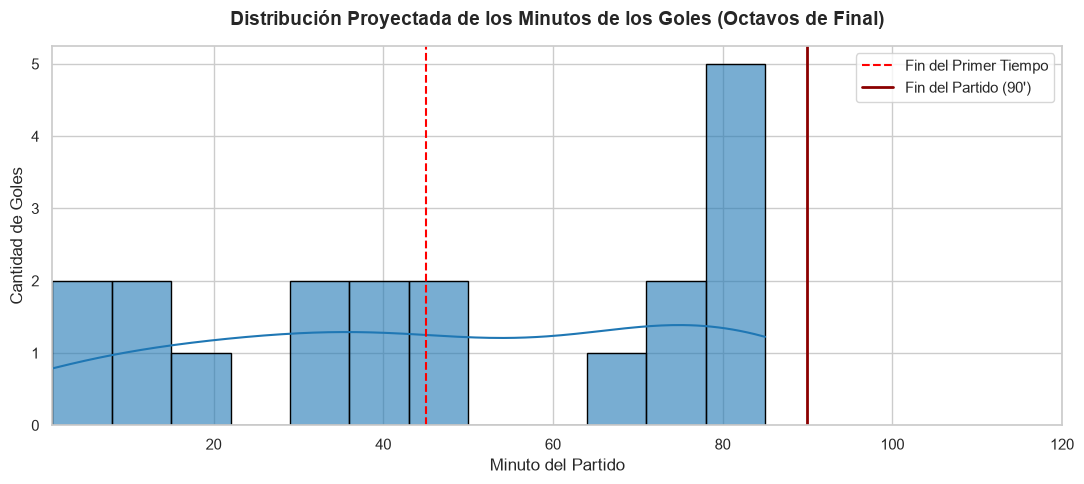

In [126]:
plt.figure(figsize=(11, 5))

# Graficar histograma con curva de densidad (KDE)
sns.histplot(
    todos_los_minutos_goles, 
    bins=12, 
    kde=True, 
    color='#1f77b4', 
    edgecolor='black',
    alpha=0.6
)

# Líneas guía para marcar los tiempos de juego
plt.axvline(x=45, color='red', linestyle='--', linewidth=1.5, label='Fin del Primer Tiempo')
plt.axvline(x=90, color='darkred', linestyle='-', linewidth=2, label='Fin del Partido (90\')')

plt.title('Distribución Proyectada de los Minutos de los Goles (Octavos de Final)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Minuto del Partido', fontsize=12)
plt.ylabel('Cantidad de Goles', fontsize=12)
plt.xlim(1, 120)  # Expandimos hasta el 120 para abarcar posibles prórrogas
plt.legend()
plt.tight_layout()
plt.show()

## 9. Simulación de Montecarlo: Proyección de Robustez sobre 1,000 Ejecuciones
Para eliminar el sesgo de la aleatoriedad de una única simulación, implementaremos un enfoque estocástico de Montecarlo. Ejecutaremos el torneo en cascada 1,000 veces consecutivas, registrando cuántas veces clasifica cada selección a los Cuartos de Final. Esto nos otorgará un porcentaje de certeza predictiva real para cada llave de Octavos.

In [127]:
from collections import Counter

# 1. Definir el número de iteraciones de Montecarlo
N_SIMULACIONES = 1000

# Diccionario global para contar cuántas veces clasifica cada equipo en total
conteo_clasificados = Counter()

print(f"🔄 Iniciando simulación de Montecarlo ({N_SIMULACIONES} iteraciones)...")

for i in range(N_SIMULACIONES):
    # En cada iteración corremos las llaves de octavos de forma independiente
    for _, partido in df_r16.iterrows():
        home = partido['home_team']
        away = partido['away_team']
        
        # Simular los 90 minutos reglamentarios
        gh, ga, _, _ = simular_marcador_equilibrado(home, away)
        
        # Resolver prórrogas o penales de forma estocástica si hay empate
        _, _, _, ganador, _ = resolver_desempate(home, away, gh, ga)
        
        # Sumar la victoria en el clasificado de esta simulación
        conteo_clasificados[ganador] += 1

print("✅ ¡Simulación de Montecarlo finalizada de forma impecable!\n")

# 2. Procesar y desplegar las probabilidades de éxito por llave de Octavos
print("📊 PROBABILIDADES REALES DE CLASIFICACIÓN A CUARTOS DE FINAL:")
print("=" * 65)

for _, partido in df_r16.iterrows():
    home = partido['home_team']
    away = partido['away_team']
    
    # Extraer las victorias conseguidas en las 1,000 corridas
    exitos_home = conteo_clasificados[home]
    exitos_away = conteo_clasificados[away]
    
    # Calcular el porcentaje estadístico puro
    pct_home = round((exitos_home / N_SIMULACIONES) * 100, 2)
    pct_away = round((exitos_away / N_SIMULACIONES) * 100, 2)
    
    favorito = home if pct_home > pct_away else away
    print(f"🏟️  {home} ({pct_home}%) vs {away} ({pct_away}%)")
    print(f"    ➡️  Favorito Estadístico: ¡{favorito}!\n")

🔄 Iniciando simulación de Montecarlo (1000 iteraciones)...
⏳ ¡Prórroga activa para Canada vs Morocco! (Marcador 90': 1-1)
🎯 Definición por Penales obligatoria...
⏳ ¡Prórroga activa para Switzerland vs Colombia! (Marcador 90': 1-1)
🎯 Definición por Penales obligatoria...
⏳ ¡Prórroga activa para Canada vs Morocco! (Marcador 90': 1-1)
🎯 Definición por Penales obligatoria...
⏳ ¡Prórroga activa para Switzerland vs Colombia! (Marcador 90': 0-0)
⏳ ¡Prórroga activa para Croatia vs Spain! (Marcador 90': 0-0)
🎯 Definición por Penales obligatoria...
⏳ ¡Prórroga activa para United States vs Belgium! (Marcador 90': 1-1)
🎯 Definición por Penales obligatoria...
⏳ ¡Prórroga activa para Canada vs Morocco! (Marcador 90': 2-2)
⏳ ¡Prórroga activa para Mexico vs England! (Marcador 90': 0-0)
🎯 Definición por Penales obligatoria...
⏳ ¡Prórroga activa para Paraguay vs France! (Marcador 90': 2-2)
🎯 Definición por Penales obligatoria...
⏳ ¡Prórroga activa para Paraguay vs France! (Marcador 90': 2-2)
🎯 Definició

## 10. Visualización de Probabilidades de Montecarlo
A continuación, graficaremos mediante un diagrama de barras el porcentaje de éxito obtenido por cada selección a lo largo de las 1,000 simulaciones del torneo, permitiéndonos contrastar visualmente la solidez de los favoritos.

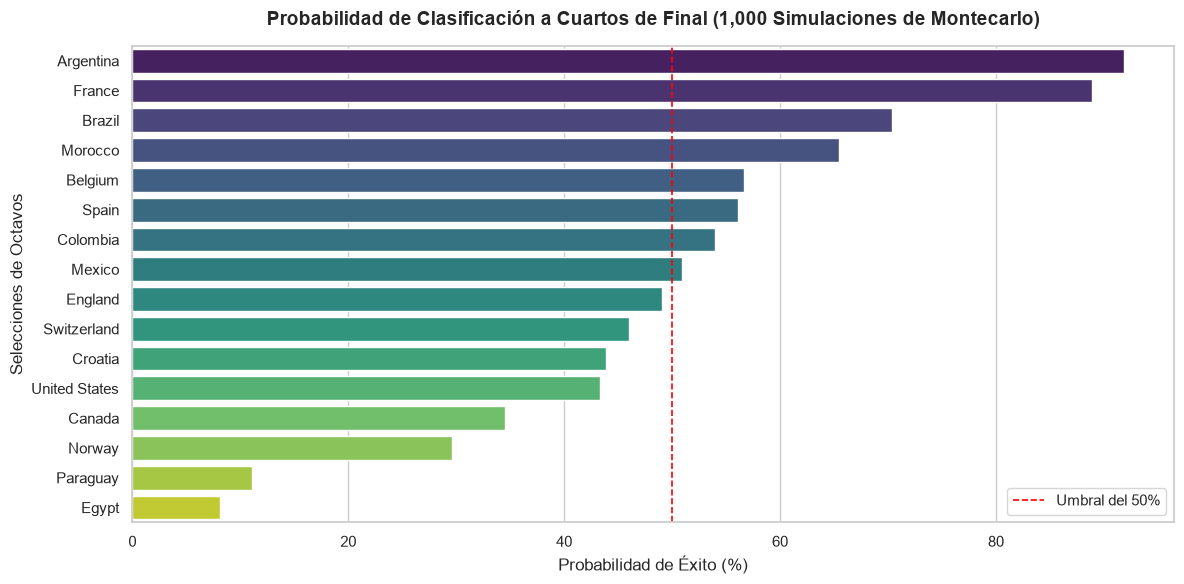

In [128]:
# Convertir los resultados de Montecarlo a un DataFrame de Pandas
df_montecarlo = pd.DataFrame(conteo_clasificados.items(), columns=['Selección', 'Clasificaciones'])
df_montecarlo['Probabilidad_Éxito_%'] = round((df_montecarlo['Clasificaciones'] / N_SIMULACIONES) * 100, 2)
df_montecarlo = df_montecarlo.sort_values(by='Probabilidad_Éxito_%', ascending=False).reset_index(drop=True)

# Graficar los resultados con Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_montecarlo,
    x='Probabilidad_Éxito_%',
    y='Selección',
    palette='viridis',
    hue='Selección',
    legend=False
)

plt.axvline(x=50, color='red', linestyle='--', linewidth=1.2, label='Umbral del 50%')
plt.title('Probabilidad de Clasificación a Cuartos de Final (1,000 Simulaciones de Montecarlo)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Probabilidad de Éxito (%)', fontsize=12)
plt.ylabel('Selecciones de Octavos', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()